In [12]:
import numpy as np
import random


第一題:生成九個點(0,1)uniform點，任兩點距離不在0.1內。

演算法:
step1 設定初始9個uniform(0,1)點，X1.......X9 任兩點距離不內0.1內，

step2 生成u~(0,1) 設定I=int(9*u) 代表被選中的XI 。再生成一個 U~(0,1) 若 U 跟XI之外的八個點，距離皆不在0.1內。 U將取代XI。重複執行此動作。



In [ ]:
# step1 設定初始九個點，任兩點距離不在0.1內。
list=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
list=np.array(list)
list

In [ ]:
#step2 執行10000000次

for i in range(10000000):
    u=random.uniform(0,1)
    I=int(9*u) #python index 從0開始，因此I=0....8，隨機選XI
    U=random.uniform(0,1) #生成U(0,1)
    x=list[:I]
    y=list[I+1:]
    X=np.hstack([x,y]) #X等於XI之外，另外八個點
    arr=abs(X-U)
    if (arr.min()>0.1)==True: #若八個點跟U的距離最小值都大於0.1，表示所有距離都大於0.1。
        list[I]=U #滿足上述條件替換XI=U
        
print(list)

第二題 a 算 E(x1+2x2+3x3 | x1+2x2+3x3>15)  x1,x2,x3 ~exp(1) 彼此獨立


演算法:
step1 生成第一組X1(x1 + 2x2+ 3x3) 條件為 x1+2x2+3x3>15 ,k=1

step2 I=0

step3 I=I+1

I=1      a=15-2x2-3x3  U~(0,1) x1新=-logU + a      gibbs 生成新x1 用2x2,3x3當條件生，且新生成x必須滿足x1+2x2+3x3>15條件，a如果小於0表示已達成條件，set a =0 下一個x隨便生就好 ，若a>0表示條件沒被滿足 ，下個 x 必須要 >a才行，又指數分配有遺失性，所以直接從a開始生成也合理 。

I=2      a=15-x1-3x3   U~(0,1) 2x2新= 2*-logU + a  (因為2x2== 2*exp(1)，所以生成 2*-logU)

I=3      a=15-x1-2x2   U~(0,1) 3x3新= 3*-logU + a  (因為3x3== 3*exp(1)，所以生成 3*-logU)

step4 得出 X2=(x1新,2x2新,3x3新) 回到step 2

step5 重複step2-4多次 得出 X1......XK  K=10000

In [ ]:
#np.random.exponential(scale=1)

In [13]:
#step 1 生成第一組X1(x1 + 2x2+ 3x3) on x1+2x2+3x3>15 k=1
X=[]
xk_1=[]
while True:
    x1=np.random.exponential(scale=1)
    x2=2*np.random.exponential(scale=1)
    x3=3*np.random.exponential(scale=1)
    if x1+x2+x3>15:
        xk_1.append(x1)
        xk_1.append(x2)
        xk_1.append(x3)
        X.append(xk_1)
        break

In [14]:
X

[[1.7322453204620232, 7.214950385866033, 7.792902826365729]]

In [15]:
#set 初始 x1 x2 x3
import math
x1=X[0][0]
x2=X[0][1]
x3=X[0][2]

In [16]:
for i in range(10000): #step5 k=10000 執行10000遍
    I=0             #step 2
    while I<4:
        I=I+1       #step3 I=I+1
        if(I==1):
            a=15-x2-x3
            if a<0:  # a>=0 ，if a<0 set a=0
                a=0
                u=random.uniform(0,1)
                x1=-math.log(u)+a 
            else:
                a=a
                u=random.uniform(0,1)
                x1=-math.log(u)+a #
        if (I==2):
            a=15-x1-x3
            if a<0:
                a=0
                u=random.uniform(0,1)
                x2=-2*math.log(u)+a 
            else:
                a=a
                u=random.uniform(0,1)
                x2=-2*math.log(u)+a
        if (I==3):
            a=15-x1-x2
            if a<0:
                a=0
                u=random.uniform(0,1)
                x3=-3*math.log(u)+a
            else:
                a=a
                u=random.uniform(0,1)
                x3=-3*math.log(u)+a
    list=[x1,x2,x3]
    X.append(list) #step4 得到  Xk(x1,2x2,3x3) back to step2

In [17]:
X[0:5]

[[1.7322453204620232, 7.214950385866033, 7.792902826365729],
 [1.7282675159054193, 5.659550596509115, 7.847438030749539],
 [1.7682216317947326, 11.640384534201136, 8.258839327863814],
 [1.1661525929368972, 5.905324816554354, 11.378843178386848],
 [0.5977292978822388, 3.224863805836898, 11.38613015623375]]

In [18]:
X=X[2000:] #burn in 前1999筆資料

In [19]:
len(X)

8001

In [20]:
#compute期望值 E(x1+2x2+3x3 | x1+2x2+3x3>15)
list=[]

for i in range(len(X)):
    sum=np.sum(X[i])
    list.append(sum)
    
E=np.sum(list)/len(list)
print(E)

18.141837061382887


(array([2903., 1910., 1279.,  826.,  572.,  312.,  140.,   42.,   10.,
           7.]),
 array([7.27485421e-04, 2.40633937e+00, 4.81195126e+00, 7.21756315e+00,
        9.62317503e+00, 1.20287869e+01, 1.44343988e+01, 1.68400107e+01,
        1.92456226e+01, 2.16512345e+01, 2.40568464e+01]),
 <BarContainer object of 10 artists>)

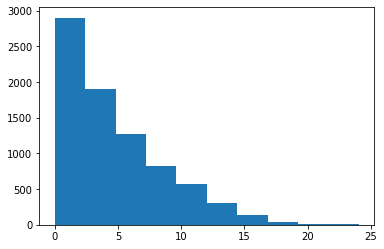

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline
x2=[]
for i in range(len(X)):
    x2.append(X[i][1])
plt.hist(x2)

In [ ]:
#========================================================

第二題 b 算 E(x1+2x2+3x3 | x1+2x2+3x3<1)  x1,x2,x3 ~exp(1) 彼此獨立


演算法:
step1 生成第一組X1(x1 + 2x2+ 3x3) 條件為 x1+2x2+3x3<1 ,k=1

step2 I=0

step3 I=I+1

I=1      a=1-2x2-3x3  U~(0,1)  y= (-logU)~ exp(1)           x1新 = a - y     ， gibbs 生成新x1 用2x2,3x3當條件生，且新生成x必須滿足x1+2x2+3x3<1條件，a必定要>0，因為a代表有多少額度可生成x，若a小於0就沒有額度生了。 y必定小於a 且大於0，x1才會符合指數分配 x不得為負

I=2      a=1-x1-3x3   U~(0,1)  y= 2*(-logU)  (y必定小於a 且大於0)        2x2新= a-y  (因為2x2== 2*exp(1)，所以生成 2*-logU)

I=3      a=1-x1-2x2   U~(0,1)  y= 3*(-logU)  (y必定小於a 且大於0)        3x3新= a-y  (因為3x3== 3*exp(1)，所以生成 3*-logU)

step4 得出 X2=(x1新,2x2新,3x3新) 回到step 2

step5 重複step2-4多次 得出 X1......XK  K=10000

In [ ]:
X=[]
xk_1=[]
while True:
    x1=np.random.exponential(scale=1)
    x2=2*np.random.exponential(scale=1)
    x3=3*np.random.exponential(scale=1)
    if x1+x2+x3<1:
        xk_1.append(x1)
        xk_1.append(x2)
        xk_1.append(x3)
        X.append(xk_1)
        break

In [ ]:
X

In [ ]:
x1=X[0][0]
x2=X[0][1]
x3=X[0][2]

In [ ]:
for i in range(10000):
    I=0
    while I<4:
        I=I+1
        if(I==1):
            a=1-x2-x3    # a= x1 可用額度，必定大於0
            while True:
                u=random.uniform(0,1)
                y=-math.log(u) # y必須<a ，只剩a額度可用，超過就不滿足條件。 重複生成y直到滿足條件才往下步走
                if  y<a:
                    y=y
                    x1=a-y
                    break
 
        if (I==2):
            a=1-x1-x3
            while True:
                u=random.uniform(0,1)
                y=-2*math.log(u) # y必須  0< y <a
                if y<a:
                    y=y
                    x2=a-y
                    break
                    
        if (I==3):
            a=1-x1-x2
            while True:
                u=random.uniform(0,1)
                y=-3*math.log(u) # y必須  0< y <a
                if y<a:
                    y=y
                    x3=a-y
                    break
    list=[x1,x2,x3]
    X.append(list)

In [ ]:
X[0:5]

In [ ]:
X=X[2000:] #burn in 前1999筆資料

In [ ]:
#compute期望值 E(x1+2x2+3x3 | x1+2x2+3x3<1)
list=[]

for i in range(len(X)):
    sum=np.sum(X[i])
    list.append(sum)
    
E=np.sum(list)/len(list)
print(E)